# TamBERT Natural Language Inference

## Setup the Env

In [13]:
import numpy as np
import pandas as pd
import tensorflow as tf
import random
from matplotlib import pyplot as plt
import IPython
random.seed(42)

In [14]:
! gdown 196RTClD2_Yg7xpXhQ3Mn0FVSD9vBeuBo

Downloading...
From (original): https://drive.google.com/uc?id=196RTClD2_Yg7xpXhQ3Mn0FVSD9vBeuBo
From (redirected): https://drive.google.com/uc?id=196RTClD2_Yg7xpXhQ3Mn0FVSD9vBeuBo&confirm=t&uuid=c48f853c-8ef5-4241-b234-6e9259d2411c
To: /content/indicxnli_tamil.zip
100% 39.6M/39.6M [00:00<00:00, 47.7MB/s]


In [15]:
!unzip /content/indicxnli_tamil.zip

Archive:  /content/indicxnli_tamil.zip
replace indicxnli_tamil/dev.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: indicxnli_tamil/dev.json  
replace indicxnli_tamil/test.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: indicxnli_tamil/test.json  
replace indicxnli_tamil/train.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: indicxnli_tamil/train.json  


In [16]:
import json

def data_to_df(filepath):

  split_path = filepath.split('/')[-1]
  split_path = split_path.split('.')[0]
  if split_path == 'dev':
    split_path = 'validation'

  with open(filepath, 'r') as file:
    data = json.load(file)

    df = pd.DataFrame(data[split_path])
    df.rename(columns={'premise':'sentence1', 'hypothesis':'sentence2', 'label': 'gold_label'}, inplace=True)
    return df

In [17]:
# Get all the dfs
train_df = data_to_df('indicxnli_tamil/train.json')
dev_df = data_to_df('indicxnli_tamil/dev.json')
test_df = data_to_df('indicxnli_tamil/test.json')

In [18]:
dev_df.head()

,sentence1,sentence2,gold_label
0,"அவர் சொன்னார், ""அம்மா, நான் வீட்டிற்கு வந்துவி...",பள்ளிப் பேருந்து அவனைக் கீழே இறக்கிய உடனே அவன்...,1
1,"அவர் சொன்னார், ""அம்மா, நான் வீட்டிற்கு வந்துவி...",அவர் ஒரு வார்த்தை கூட பேசவில்லை.,2
2,"அவர் சொன்னார், ""அம்மா, நான் வீட்டிற்கு வந்துவி...",தன் தாயை வீட்டிற்கு அழைத்துச் சென்றிருப்பதாகச்...,0
3,நான் எதற்காக செல்கிறேன் அல்லது எதுவுமே எனக்குத...,"நான் வாஷிங்டனுக்கு ஒருபோதும் சென்றதில்லை, எனவே...",1
4,நான் எதற்காக செல்கிறேன் அல்லது எதுவுமே எனக்குத...,நான் வாஷிங்டனுக்கு அணிவகுத்துச் சென்றபோது நான்...,2


In [19]:
def sentence_sampler(category, n=10):
  """
  Prints a sample of sentences with a certain label of relationship (category) from train set

  INPUTS:
    category (string): category of relationship
    n (int): sample size
  """
  sample = test_df[test_df.gold_label == category].sample(n)
  for index, row in sample.iterrows():
    print("Sentence1:")
    print(row['sentence1'])
    print("Sentence2:")
    print(row['sentence2'])
    print("\n")

In [20]:
print("EXAMPLES OF CONTRADICTION:")
print("\n")
sentence_sampler(2)

print("EXAMPLES OF ENTAILMENT:")
print("\n")
sentence_sampler(0)

print("EXAMPLES OF NEUTRAL:")
print("\n")
sentence_sampler(1)

EXAMPLES OF CONTRADICTION:


Sentence1:
இது கதை சொல்வதற்கு வருடத்தின் ஒரு அற்புதமான நேரம்.
Sentence2:
கதை சொல்ல டிசம்பர் வரை காத்திருப்பேன்.


Sentence1:
தேசங்களும் இனத் தொகுதியினரும் அவ்வளவு நம்பிக்கையுள்ளவர்களாய் இருக்கிறார்கள், தங்களைப்பற்றி அவ்வளவு திருப்தியடைந்திருப்பதால், இனப் பெயர்கள் யானையின் கூழாங்கற்களைப் போல் அல்லது வேடிக்கையாக அல்லது அலங்காரப் பொருளாக ஏற்றுக்கொள்ளப்படுகின்றன.
Sentence2:
எல்லா இனக்குழுக்களும் தங்களைப்பற்றி வெட்கப்படுகின்றனர்.


Sentence1:
துறைமுக நகரான நாஃப்ளியோ இப்பகுதியை சுற்றிப்பார்க்க உகந்த தளமாக உள்ளது, அல்லது உங்கள் சுற்றுப்பயணத்தின் போது மதிய உணவு சாப்பிட ஒரு இடமாக இருக்கலாம்.
Sentence2:
Nafplio ஒரு மோசமான அடித்தளம்.


Sentence1:
"நான் உங்களுக்குக் கடன்பட்டிருக்கிறேன்-- அல்லது நான் அவ்வாறு நினைத்தேன்," என்று அவர் கூறினார்.
Sentence2:
அவர் நீங்கள் எதுவும் கடன்பட்டிருக்க வேண்டும் என்று நினைக்கவில்லை.


Sentence1:
பல்வேறு உத்தியோகபூர்வ ஆவணங்களை ஆராய்வதைத் தவிர, செக் அரசாங்கம் ஈராக் தூதரகத்திற்கு வெளியே எடுக்கப்பட்ட கண்காணிப்பு நிழற்படங்களையும் ஆய்வு செய்

In [21]:
train_df.groupby('gold_label').count()

,sentence1,sentence2
gold_label,,
0,130899,130899
1,130900,130900
2,130903,130903


In [22]:
test_df.groupby('gold_label').count()

,sentence1,sentence2
gold_label,,
0,1670,1670
1,1670,1670
2,1670,1670


In [23]:
dev_df.groupby('gold_label').count()

,sentence1,sentence2
gold_label,,
0,1080,1080
1,1079,1079
2,1079,1079


## Data Exploration

### Check distribution sentence lengths

In [28]:
dev_df['sen1_len'] = dev_df['sentence1'].apply(len)
dev_df['sen2_len'] = dev_df['sentence2'].apply(len)
dev_df['sen1 - sen2'] = dev_df['sen1_len'] - dev_df['sen2_len']

test_df['sen1_len'] = test_df['sentence1'].apply(len)
test_df['sen2_len'] = test_df['sentence2'].apply(len)
test_df['sen1 - sen2'] = test_df['sen1_len'] - test_df['sen2_len']

train_df['sen1_len'] = train_df['sentence1'].apply(len)
train_df['sen2_len'] = train_df['sentence2'].apply(len)
train_df['sen1 - sen2'] = train_df['sen1_len'] - train_df['sen2_len']

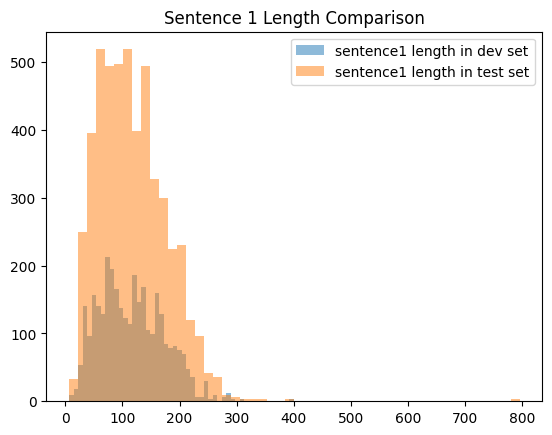

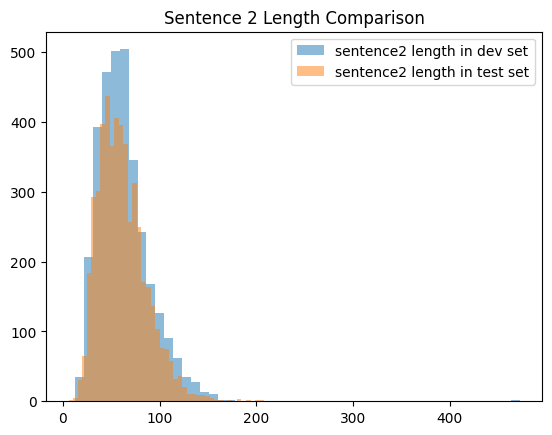

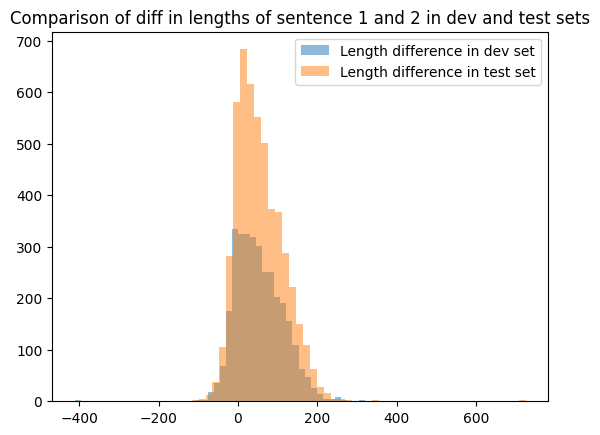

In [30]:
plt.hist(dev_df['sen1_len'], bins=50, label="sentence1 length in dev set", alpha=0.5)
plt.hist(test_df['sen1_len'], bins=50, label="sentence1 length in test set", alpha=0.5)
# plt.hist(train_df['sen1_len'], bins=50, label="sentence1 length in test set", alpha=0.5)
plt.title("Sentence 1 Length Comparison")
plt.legend(loc='best')
plt.show()

plt.hist(dev_df['sen2_len'], bins=50, label="sentence2 length in dev set", alpha=0.5)
plt.hist(test_df['sen2_len'], bins=50, label="sentence2 length in test set", alpha=0.5)
# plt.hist(train_df['sen2_len'], bins=50, label="sentence2 length in test set", alpha=0.5)
plt.title("Sentence 2 Length Comparison")
plt.legend(loc='best')
plt.show()

plt.hist(dev_df['sen1 - sen2'], bins=50, label="Length difference in dev set", alpha=0.5)
plt.hist(test_df['sen1 - sen2'], bins=50, label="Length difference in test set", alpha=0.5)
# plt.hist(train_df['sen1 - sen2'], bins=50, label="Length difference in test set", alpha=0.5)
plt.title("Comparison of diff in lengths of sentence 1 and 2 in dev and test sets")
plt.legend(loc='best')
plt.show()

### Compare vocabularies

In [31]:
def unique_words_seperator(col):
  words_list = list(col.str.split(" ", expand=True).stack().unique())
  # Remove punctuation
  rec_words_list = [w.strip('.,:()[]') for w in words_list]
  return rec_words_list

In [34]:
def common_words_finder(vocab1, vocab2):
  common_vocab = [word for word in vocab1 if word in vocab2]
  return common_vocab

In [36]:
dev_s1 = unique_words_seperator(dev_df['sentence1'])
dev_s2 = unique_words_seperator(dev_df['sentence2'])
dev_vocab = dev_s1 + dev_s2
dev_vocab = list(set(dev_vocab))

test_s1 = unique_words_seperator(test_df['sentence1'])
test_s2 = unique_words_seperator(test_df['sentence2'])
test_vocab = test_s1 + test_s2
test_vocab = list(set(test_vocab))

print("Number of unique words in dev set: ", str(len(dev_vocab)))
print("Number of unique words in test set: ", str(len(test_vocab)))
print("Number of unique common words in dev and test set: ", str(len(common_words_finder(dev_vocab, test_vocab))))
print("percentage of common words in test set: ", str(len(common_words_finder(dev_vocab, test_vocab)) / len(test_vocab)))

Number of unique words in dev set:  10787
Number of unique words in test set:  18002
Number of unique common words in dev and test set:  4878
percentage of common words in test set:  0.2709698922341962


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset

MODEL_PATH = "/content/drive/MyDrive/tambert-mlm"  # your pretrained checkpoint

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH, num_labels=3)

def tokenize_fn(batch):
    return tokenizer(batch["sentence1"], batch["sentence2"], truncation=True, padding="max_length", max_length=128)

train_ds = Dataset.from_pandas(train_df[["sentence1", "sentence2", "gold_label"]]).map(tokenize_fn, batched=True)
dev_ds = Dataset.from_pandas(dev_df[["sentence1", "sentence2", "gold_label"]]).map(tokenize_fn, batched=True)
train_ds = train_ds.rename_column("gold_label", "labels")
dev_ds = dev_ds.rename_column("gold_label", "labels")

args = TrainingArguments(
    output_dir="./tambert-nli",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    eval_strategy="epoch",
    save_strategy="epoch",
)

trainer = Trainer(model=model, args=args, train_dataset=train_ds, eval_dataset=dev_ds)
trainer.train()

OR

In [ ]:
from transformers import PreTrainedTokenizerFast
tokenizer = PreTrainedTokenizerFast(tokenizer_file=f"{MODEL_PATH}/tokenizer.json",
                                     cls_token="[CLS]", sep_token="[SEP]", pad_token="[PAD]",
                                     unk_token="[UNK]", mask_token="[MASK]")